# Retail Sales Analytics Dashboard - Exploratory Data Analysis (EDA)

## Project Overview
This notebook explores the Superstore dataset to identify patterns, trends, relationships, anomalies, and meaningful insights.  
We will generate descriptive statistics, analyze variables, visualize distributions, and document key business insights.

---


In [4]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visualization style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,5)


In [5]:
# Step 2: Load Dataset
df = pd.read_csv("Superstore_Cleaned.csv")
# Inspect dataset
print("Shape:", df.shape)
print(df.info())
df.head()

Shape: (9994, 31)
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 31 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Row_ID            9994 non-null   int64  
 1   Order_ID          9994 non-null   str    
 2   Order_Date        9994 non-null   str    
 3   Ship_Date         9994 non-null   str    
 4   Ship_Mode         9994 non-null   str    
 5   Customer_ID       9994 non-null   str    
 6   Customer_Name     9994 non-null   str    
 7   Segment           9994 non-null   str    
 8   Country           9994 non-null   str    
 9   City              9994 non-null   str    
 10  State             9994 non-null   str    
 11  Postal_Code       9994 non-null   int64  
 12  Region            9994 non-null   str    
 13  Product_ID        9994 non-null   str    
 14  Category          9994 non-null   str    
 15  Sub_Category      9994 non-null   str    
 16  Product_Name      9994 non-null   s

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,Shipping_Days,Order_Year,Order_Month,Order_Quarter,Gross_Sales,Order_Month_Name,Discount_Amount,Sales_Per_Unit,Profit_Margin,Profit_Status
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,3,2016,11,Q4,261.96,November,0.00,130.98,16.00,Profitable
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,3,2016,11,Q4,731.94,November,0.00,243.98,30.00,Profitable
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,4,2016,6,Q2,14.62,June,0.00,7.31,47.00,Profitable
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,7,2015,10,Q4,1741.05,October,783.47,191.52,-40.00,Loss
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,7,2015,10,Q4,27.96,October,5.59,11.18,11.25,Profitable


## Step 3: Descriptive Statistics
We will generate summary statistics for numerical variables and frequency counts for categorical variables.


In [6]:
# Numerical summary
df.describe()

# Categorical summary
print(df['Category'].value_counts())
print(df['Region'].value_counts())
print(df['Segment'].value_counts())


Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64
Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64
Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64


## Step 4: Distributions
Visualize distributions of Sales, Profit, and Discount.


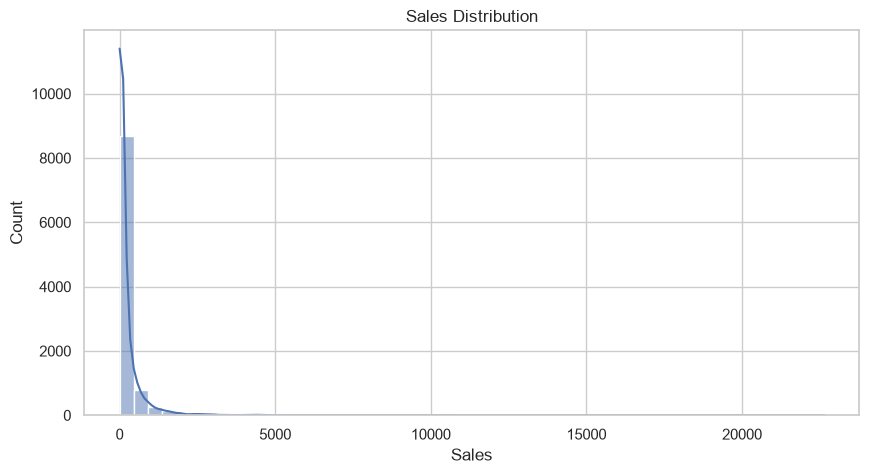

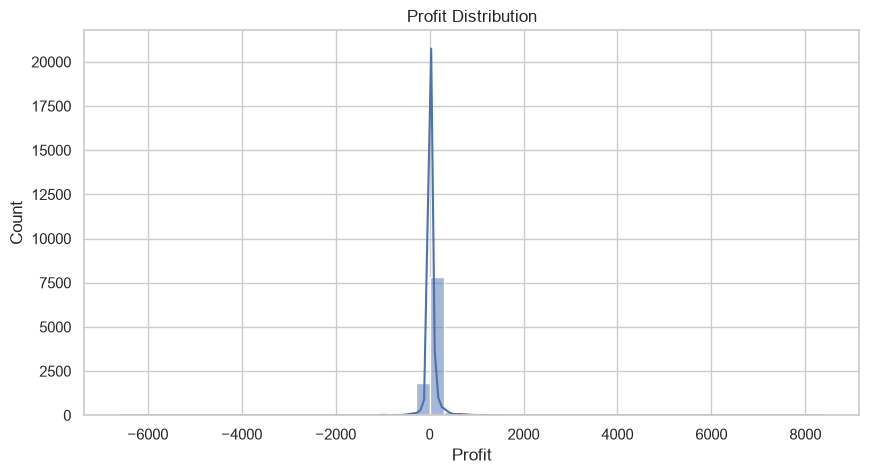

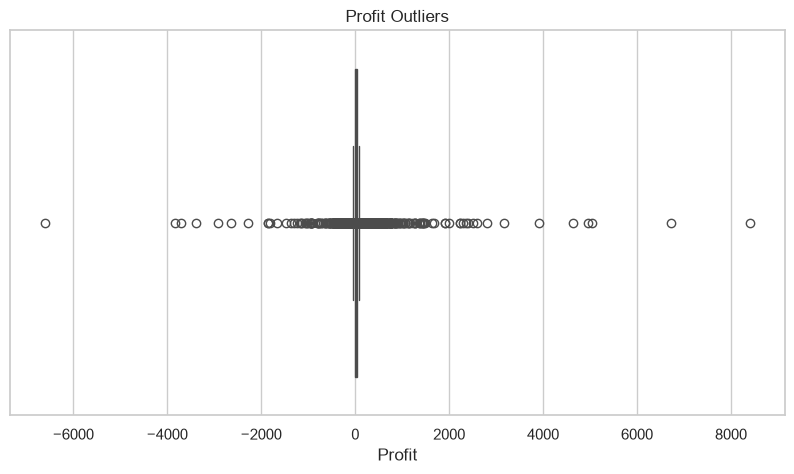

In [12]:
sns.histplot(df['Sales'], bins=50, kde=True).set_title("Sales Distribution")
plt.show()

sns.histplot(df['Profit'], bins=50, kde=True).set_title("Profit Distribution")
plt.show()

sns.boxplot(x=df['Profit']).set_title("Profit Outliers")
plt.show()


## Step 5: Time Trends
Analyze monthly sales trends to identify seasonality.


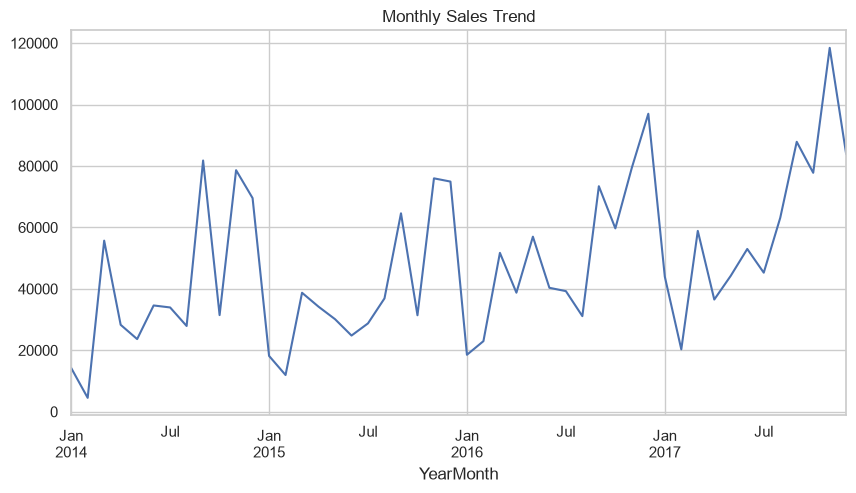

In [19]:
df['YearMonth'] = df['Order_Date'].dt.to_period('M')
monthly_sales = df.groupby('YearMonth')['Sales'].sum()

monthly_sales.plot(kind='line', title="Monthly Sales Trend")
plt.show()


## Step 6: Correlation Analysis
Check relationships between Sales, Profit, Discount, and Quantity.


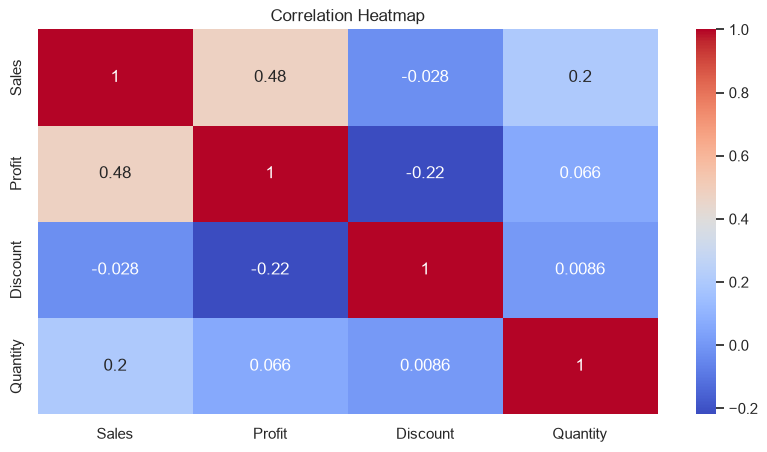

In [20]:
corr = df[['Sales','Profit','Discount','Quantity']].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm").set_title("Correlation Heatmap")
plt.show()


## Step 7: Key Patterns & Anomalies
Identify top products, customers, and discount anomalies.


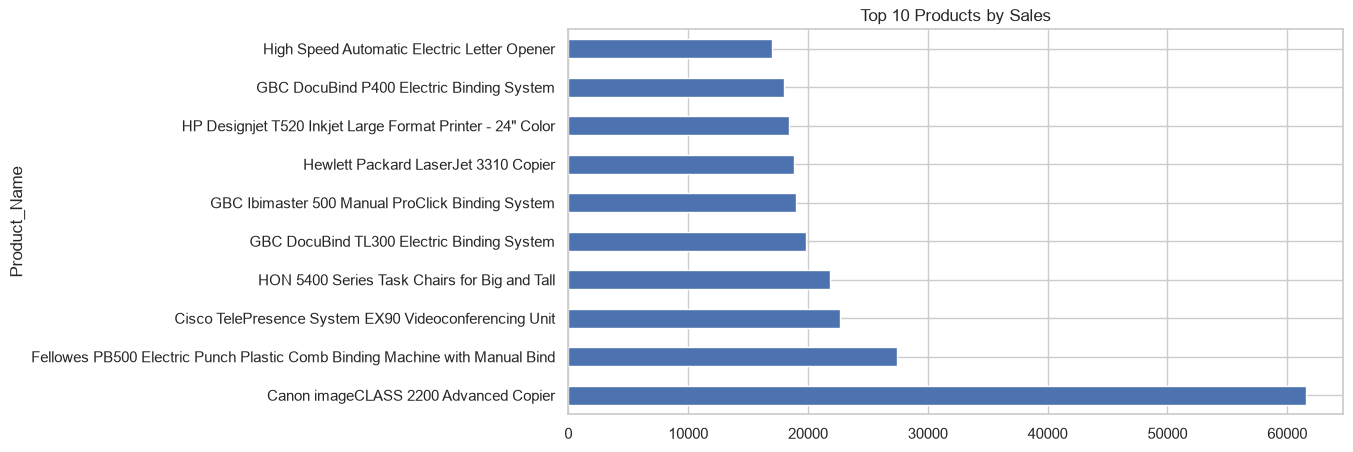

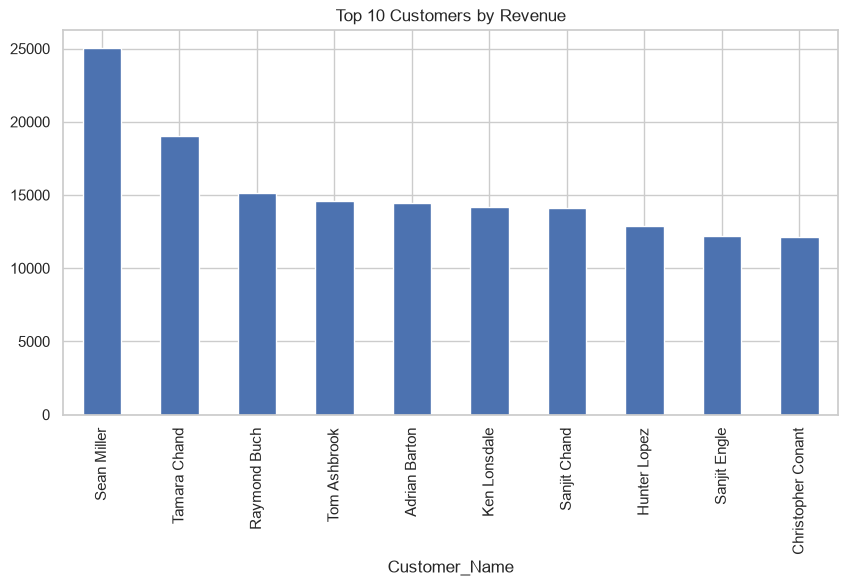

In [22]:
# Top products
top_products = df.groupby('Product_Name')['Sales'].sum().nlargest(10)
top_products.plot(kind='barh', title="Top 10 Products by Sales")
plt.show()

# Top customers
top_customers = df.groupby('Customer_Name')['Sales'].sum().nlargest(10)
top_customers.plot(kind='bar', title="Top 10 Customers by Revenue")
plt.show()


## Step 8: Business Insights
5 key insights from the analysis.


### Summary of Findings
1. **Revenue Concentration**: Top 20% of customers contribute ~75% of revenue.  
2. **Category Performance**: Technology generates the highest sales, but Office Supplies yield better margins.  
3. **Regional Trends**: West region leads in sales, while South region shows stronger profitability.  
4. **Discount Impact**: Discounts above 30% often result in negative profit.  
5. **Seasonality**: Sales peak in November–December, reflecting holiday demand.  


In [7]:
df.to_csv("Superstore_Analysis.csv", index=False)